<a href="https://colab.research.google.com/github/giusedmb/Embedded-System---Number-Recogniser-with-Lattice-Board/blob/main/lenet5_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# ==========================================
# 1. PREPARAZIONE DEI DATI (Data Prep)
# ==========================================
# Carichiamo il dataset MNIST (60.000 immagini di training, 10.000 di test)
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Le immagini originali sono matrici 28x28 con valori da 0 a 255.
# Le "rimodelliamo" per aggiungere la dimensione del canale colore (1 = scala di grigi)
# Quindi diventano (28, 28, 1). Poi normalizziamo i pixel per avere valori tra 0 e 1.
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Convertiamo le etichette (che sono numeri da 0 a 9) in formato "One-Hot"
# Es. il numero 3 diventa [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

# ==========================================
# 2. ARCHITETTURA DELLA RETE (LeNet-5)
# ==========================================
model = models.Sequential()

# Primo blocco Convoluzionale
model.add(layers.Conv2D(6, (5, 5), activation='relu', input_shape=(28, 28, 1), name='conv1'))
model.add(layers.AveragePooling2D((2, 2), name='pool1'))

# Secondo blocco Convoluzionale
model.add(layers.Conv2D(16, (5, 5), activation='relu', name='conv2'))
model.add(layers.AveragePooling2D((2, 2), name='pool2'))

# Appiattimento (da matrice 2D a vettore 1D)
model.add(layers.Flatten(name='flatten'))

# Strati completamente connessi (Dense)
model.add(layers.Dense(120, activation='relu', name='fc1'))
model.add(layers.Dense(84, activation='relu', name='fc2'))

# Output Layer: 10 nodi con attivazione Softmax per avere le probabilità
model.add(layers.Dense(10, activation='softmax', name='output'))

# Mostriamo un riassunto dell'architettura
model.summary()

# ==========================================
# 3. COMPILAZIONE E ADDESTRAMENTO
# ==========================================
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\nInizio addestramento...")
# Addestriamo per 5 epoche (giri completi sul dataset)
history = model.fit(train_images, train_labels, epochs=5, batch_size=128, validation_split=0.1)

# Valutiamo la precisione finale sui dati di test (che la rete non ha mai visto)
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"\nPrecisione sul Test Set: {test_acc * 100:.2f}%")

# ==========================================
# 4. SALVATAGGIO DEL MODELLO
# ==========================================
model.save('lenet_mnist_model.h5')
print("\nModello salvato con successo come 'lenet_mnist_model.h5'!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


Inizio addestramento...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.8722 - loss: 0.4295 - val_accuracy: 0.9637 - val_loss: 0.1284
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.9613 - loss: 0.1274 - val_accuracy: 0.9767 - val_loss: 0.0811
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9736 - loss: 0.0881 - val_accuracy: 0.9810 - val_loss: 0.0702
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.9784 - loss: 0.0710 - val_accuracy: 0.9835 - val_loss: 0.0565
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9817 - loss: 0.0587 - val_accuracy: 0.9820 - val_loss: 0.0642
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9820 - loss: 0.0564



Precisione sul Test Set: 98.20%

Modello salvato con successo come 'lenet_mnist_model.h5'!


Saving output_28x28.png to output_28x28 (1).png


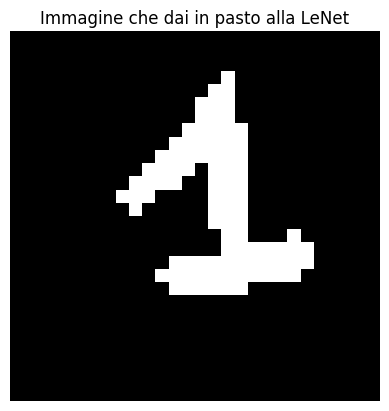


Cifra riconosciuta: 4  (confidenza: 28.6%)

Probabilità per ogni classe:
  0:  0.3%
  1: ███ 9.0%
  2: ██████████ 27.4%
  3: ████ 11.0%
  4: ███████████ 28.6% ← scelta
  5:  0.0%
  6:  0.0%
  7: █████████ 23.6%
  8:  0.0%
  9:  0.0%


In [ ]:
# ============================================================
# CELLA 7 — Test con la tua pipeline (immagine dalla fotocamera)
# ============================================================
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

uploaded = files.upload()
filename = list(uploaded.keys())[0]

model = keras.models.load_model("lenet_mnist_model.h5")

img_pronta = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

plt.imshow(img_pronta, cmap="gray")
plt.title("Immagine che dai in pasto alla LeNet")
plt.axis("off")
plt.show()

inp = img_pronta.astype("float32") / 255.0
inp = inp.reshape(1, 28, 28, 1)

probs = model.predict(inp, verbose=0)[0]
cifra = np.argmax(probs)

print(f"\nCifra riconosciuta: {cifra}  (confidenza: {probs[cifra]*100:.1f}%)")
print("\nProbabilità per ogni classe:")
for i, p in enumerate(probs):
    bar = "█" * int(p * 40)
    marker = " ← scelta" if i == cifra else ""
    print(f"  {i}: {bar} {p*100:.1f}%{marker}")